**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [12]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [13]:
from util import load_audio, plot_signals

FILEPATH = "./sis1-group102/labs/audio/audioSisLabs.wav"
x, fs = load_audio(FILEPATH)

t_start = 0.0
t_end   = 1.5

plot_signals([x], sr=fs, t_start=t_start, t_end=t_end, name=["reference"])

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

In [17]:
ff, tt, S = spectrogram(x, fs=fs, window=win, nperseg=N,
                        noverlap=N//2, nfft=N, detrend=False,
                        scaling='spectrum', mode='magnitude')

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [18]:
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 4000.0)

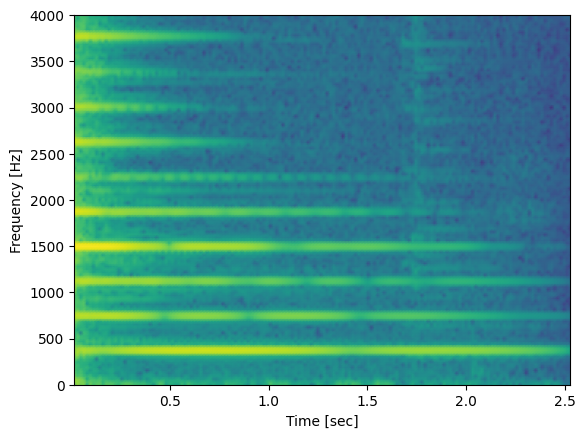

In [19]:
from scipy.signal import spectrogram, get_window
import matplotlib.pyplot as plt

N = int(0.032 * fs)
win = get_window('hann', N)


plot_spectrogram(ff, tt, S)


plt.ylim(0, 4000)


1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [ ]:
# pick the time (in seconds) after inspecting the spectrogram
t_sel = 0.30   

plot_spectrum_at(ff, tt, S, t_sel)


1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [ ]:
weights = [0.68162, 0.12600, 0.31265, 0.14200, 0.08153, 0.28873]

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [25]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

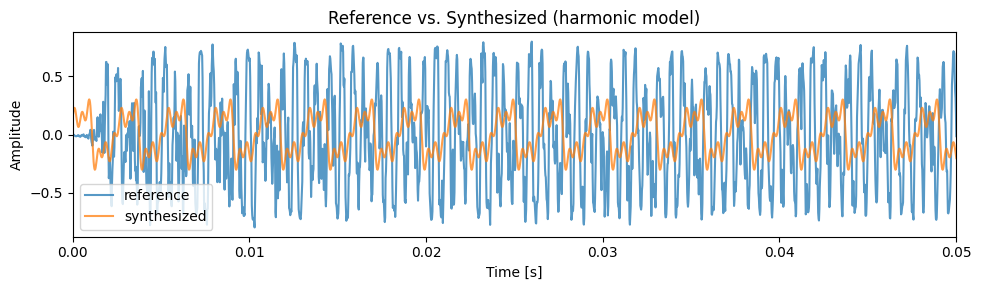

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio


f0 = 375.053  

Ak = np.array([0.68162, 0.12600, 0.31265, 0.14200, 0.08153, 0.28873])


phi = 5.28

dur = t_end - t_start
t = np.arange(0, dur, 1/fs)

n0 = int(round(t_start * fs))
n1 = n0 + len(t)
x_seg = x[n0:n1]

y = synthesize(f0, phi, Ak, t)

if np.std(y) > 0:
    y = y * (np.std(x_seg) / np.std(y))

plt.figure(figsize=(10,3))
plt.plot(t + t_start, x_seg, label='reference', alpha=0.75)
plt.plot(t + t_start, y,        label='synthesized', alpha=0.75)
plt.xlim(t_start, t_start + 0.05)   # zoom first 50 ms; adjust if you like
plt.xlabel('Time [s]'); plt.ylabel('Amplitude')
plt.title('Reference vs. Synthesized (harmonic model)')
plt.legend(); plt.tight_layout()

Audio(y, rate=fs)


2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

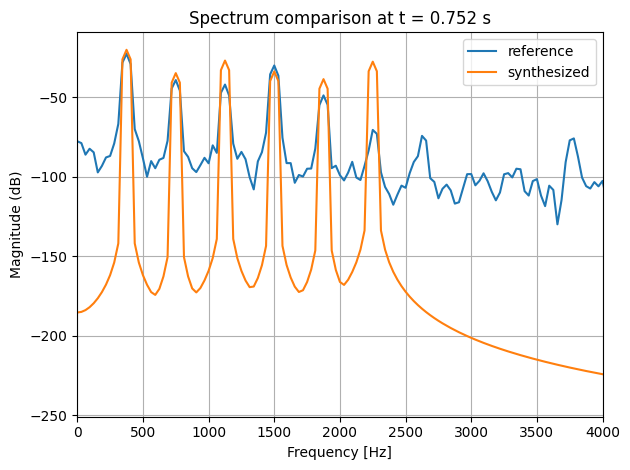

In [27]:
import numpy as np
from scipy.signal import spectrogram


ff_syn, tt_syn, S_synt = spectrogram(
    y, fs=fs, window=win, nperseg=N, noverlap=N//2, nfft=N,
    detrend=False, scaling='spectrum', mode='magnitude'
)


ff_ref, tt_ref, S_ref = spectrogram(
    x_seg, fs=fs, window=win, nperseg=N, noverlap=N//2, nfft=N,
    detrend=False, scaling='spectrum', mode='magnitude'
)


t_sel = float(tt_ref[len(tt_ref)//2])  


import matplotlib.pyplot as plt
def overlay_spectra_at(ff, ttA, SA, ttB, SB, t_sel, db=True):
    ia = int(np.argmin(np.abs(ttA - t_sel)))
    ib = int(np.argmin(np.abs(ttB - t_sel)))
    ya, yb = SA[:, ia], SB[:, ib]
    if db:
        ya = 20*np.log10(np.maximum(ya, 1e-12))
        yb = 20*np.log10(np.maximum(yb, 1e-12))
    plt.figure()
    plt.plot(ff, ya, label='reference')
    plt.plot(ff, yb, label='synthesized')
    plt.xlabel('Frequency [Hz]'); plt.ylabel('Magnitude (dB)')
    plt.title(f'Spectrum comparison at t = {t_sel:.3f} s')
    plt.xlim(0, 4000)   # zoom if you want
    plt.grid(True); plt.legend(); plt.tight_layout()

overlay_spectra_at(ff_ref, tt_ref, S_ref, tt_syn, S_synt, t_sel)


2.3. Compare the spectrograms of the two signals. What are the main differences?

The synthesized signal’s spectrogram shows only narrow, evenly spaced harmonic lines at integer multiples of (f_0), with almost no energy between them and little temporal variation, whereas the reference spectrogram has broader peaks sitting on a clear noise floor, plus faint inharmonic components and time-varying envelopes (onset/decay and slight drift). In the synth, any harmonics you didn’t include simply don’t appear (e.g., gaps for orders 2–5), and the spectrum rolls off sharply above the highest modeled partials; the reference keeps some energy at higher frequencies. These patterns imply that the synth will sound cleaner and more “pure/buzzy,” but also thinner and less textured, while the reference will sound richer and more natural due to the extra broadband energy, small detunings, and transient dynamics that the simple harmonic model doesn’t capture.


2.4. Listen to the two audios (reference and synthesized). What are the main differences?

The synthesized audio has the same pitch but sounds cleaner with very stable tones, little background noise, and fewer transients; it also feels thinner/less warm because only selected harmonics are present (e.g., missing 2–5) and high-frequency energy drops off fast. The reference audio is richer and more natural: you hear a fuller timbre, subtle breath/noise and inharmonic bits, slight level/drift changes over time, and stronger attack/decay cues.
